## Purpose

Uses a naive approach to estimate the volatility ($\sigma$) and drift ($\mu$) parameters of a stock assuming geometric Brownian motion. 

## Mathematics

Assuming geometric Brownian motion we know that the value of a stock can be expressed as

$$S_t = S_0 \ \text{exp}\left(\left(\mu - \frac{\sigma^2}{2}\right)t + \sigma W_t\right).$$

Taking the logarithm of each side we get

$$\text{log}\left(\frac{S_t}{S_0}\right) = \left(\mu - \frac{\sigma^2}{2}\right)t + \sigma W_t \ .$$

Since our stock data is discrete, we take the difference between two adjacent data points to get

$$\text{log}\left(\frac{S_{t+\Delta t}}{S_t}\right) = \left(\mu - \frac{\sigma^2}{2}\right)\Delta t + \sigma \left(W_{t + \Delta t} - W_{t}\right) \ .$$

From the definition of Brownian motion we know that the difference between two values of Brownian motion whose time differs by $\Delta t$ will form a normal distribution with variance $\Delta t$. Hence when we take the expectation value and variance of the above distribution we get

$$\mathbb{E}\left[ \text{log} \left( \frac{S_{t+\Delta t}}{S_t} \right) \right] = \left(\mu - \frac{\sigma^2}{2}\right)\Delta t $$

$$ \text{Var} \left( \text{log} \left( \frac{S_{t+\Delta t}}{S_t} \right) \right) = \sigma^2 \Delta t $$

We can then solve for $\mu$ and $\sigma$. 




In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Converting stock data to numpy arrays
stock_list = ["AAPL", "MCD", "NDX"]
array_list = []

script_location = os.path.abspath('')
os.chdir(script_location)


# Iterates through the stock_list, storing data as a numpy matrix
for stock in stock_list:

    file_location = f"daily{stock}.csv"

    with open(file_location, 'r') as file:
        
        raw_csv_data = pd.read_csv(file)
        array = raw_csv_data.to_numpy()
        array = np.transpose(array)[1]

        # Trimming excess data
        if len(array) != 3774:

            array = array[-3774:]
            
        array_list.append(array)


stock_matrix = np.array(array_list).astype(float)

In [66]:
# Calculating the expectation and variance of the log returns of the stock prices
log_diff = np.diff(np.log(stock_matrix), axis=1)
expected_value = np.average(log_diff, axis=1)
variance = np.var(log_diff, axis=1)

# Setting the units of time in days and hence taking $\Delta t$ = 1
sigma = np.sqrt(variance)
mu = expected_value + np.square(sigma)/2

# Defining a time array for future use
t = np.arange(0, len(stock_matrix[0]))

# Defining an array of normal data for future use
normal_data = np.random.normal(size = (3, len(t)))

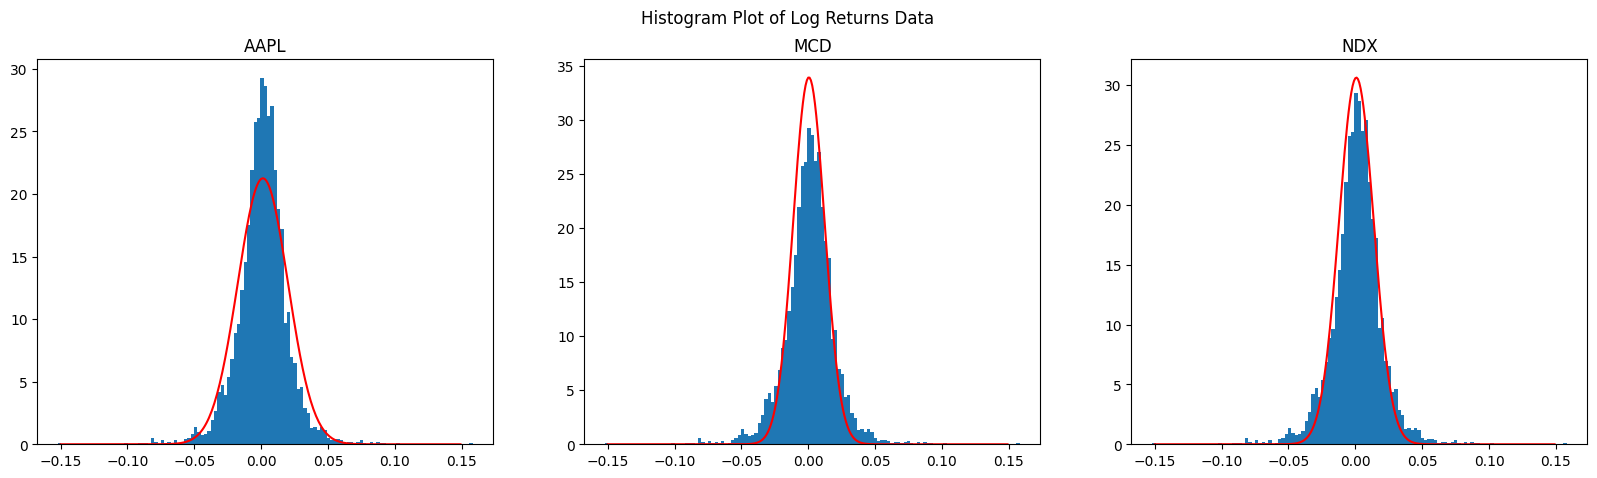

In [67]:
# Plotting probability distribution of the log returns
fig, ax_list = plt.subplots(1, 3, figsize=(20,5))
bincount = int(len(t) / 30)
fig.suptitle("Histogram Plot of Log Returns Data")

stock_values = np.arange(-0.15, 0.15, 0.001)

for i in range(len(ax_list)):
    ax_list[i].set_title(stock_list[i])
    ax_list[i].hist(log_diff[0], bins = bincount, density=True)
    ax_list[i].plot(stock_values, 1/np.sqrt(2 * np.pi * sigma[i]**2) * np.exp(-(stock_values - mu[i])**2 / 2 / sigma[i]**2), color="red")

plt.show()

In [ ]:
# Normality Testing using the Kolmogorov-Smirnov test for goodness of fit

from scipy import stats

kstest_results = []

for i in range(len(log_diff)):

    kstest = stats.kstest(log_diff[i], 'norm', args=(mu[i] - sigma[i]**2 / 2, sigma[i]))
    print(kstest)
    kstest_results.append(kstest)

KstestResult(statistic=0.061301900600926246, pvalue=9.083827397223861e-13, statistic_location=-0.009536930191581305, statistic_sign=-1)
KstestResult(statistic=0.07396091038240502, pvalue=2.1471659212127147e-18, statistic_location=-0.006384675734814493, statistic_sign=-1)
KstestResult(statistic=0.07599553488147359, pvalue=2.1327332964842587e-19, statistic_location=-0.005027274013793104, statistic_sign=-1)


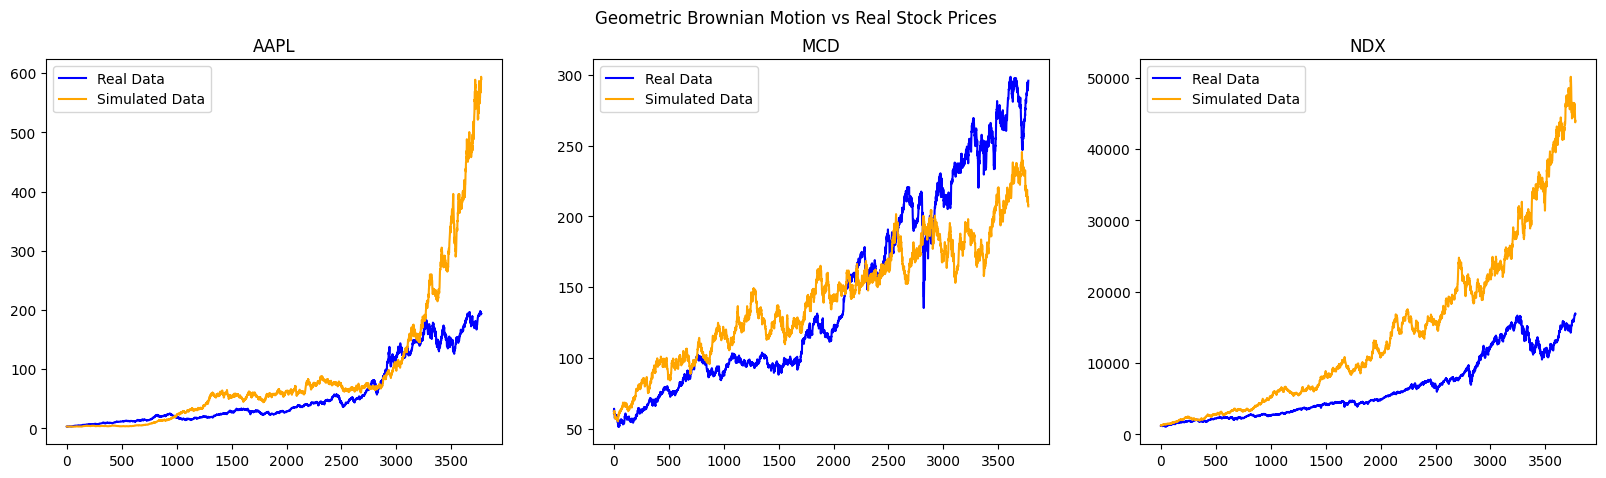

In [69]:
# Simulates Brownian motion based off normal data
def sim_gbm(S0, mu, sigma, t, W_t):

    return S0 * np.exp((mu - sigma**2 / 2) * t + sigma * W_t)

brownian_motion = np.cumsum(normal_data, axis=1)

# Plotting real stock values vs geometric brownian motion simulation
fig, ax_list = plt.subplots(1, 3, figsize=(20,5))
fig.suptitle("Geometric Brownian Motion vs Real Stock Prices")

for i in range(len(ax_list)):
    ax_list[i].set_title(stock_list[i])
    ax_list[i].plot(t, stock_matrix[i], color='blue', label='Real Data')
    ax_list[i].plot(t, sim_gbm(stock_matrix[i][0], mu[i], sigma[i], t, brownian_motion[i]), color='orange', label='Simulated Data')
    ax_list[i].legend()

plt.show()